# Project Title: HR Employee Attrition Analysis

 ## Problem Definition

The company is experiencing employee attrition and aims to understand the key factors driving employee turnover. The objective of this analysis is to identify patterns within the workforce data, uncover possible causes of attrition, and provide data-driven recommendations to improve employee retention in the future.

## HR Business Questions

To understand employee attrition and workforce behavior, the following business questions will be analyzed:

1. What is the overall attrition rate in the company?

2. Which departments have the highest attrition rate?

3. Is employee attrition influenced by monthly income (salary levels)?

4. Are younger employees more likely to leave the company?

5. Do employees with fewer years at the company show higher attrition?

6. Is there a relationship between job level and employee retention?

7. Which departments have the highest and lowest average salaries?

8. How does employee age vary between employees who stay and those who leave?

9. Does employee attrition vary by gender?

10. Are there salary differences across genders?

11. What key factors are most strongly associated with employee attrition?

12. What are the potential risks if current attrition trends continue?

13. What recommendations can be made to reduce employee turnover in the future?

Now we will do Analysis for each question one by one After Loading the Data and afterwards we will write Findings and Professional Suggestions.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("D:\HR_Employee_Attrition.csv")
# Display the first few rows of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Let's Examine the dataset to see the data summary and clean it if needed.

In [4]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Result:
Data type of each column is correct so we don't have to convert any column's data type.

In [5]:
# Check for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Result:
There is no missing values (nor any empty data cell that can not be detect by pandas).

In [6]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

## Result: 
There is no duplicate values in the dataset.

# Conclusion:
As the Data is already Clean and has no null values and zero duplicates.
So we will move ahead to EDA.

Firstly, we will identify the categorical and numerical columns so that we can apply the respective staticstical tests

In [ ]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

### Question 1:
What is the overall attrition rate in the company?

In [ ]:
# Calculate overall attrition rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_rate.round(2))

## Insight:
The company has a noticeable attrition rate, indicating a significant portion of employees have left, which requires further investigation into underlying causes.

### Question 2:
Which departments have the highest attrition rate?

In [ ]:
# Calculate attrition percentage by department
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
print(dept_attrition.round(2))

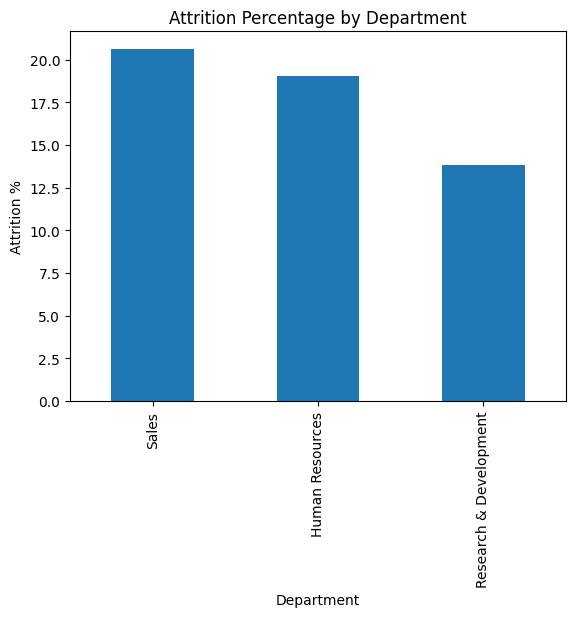

In [9]:
# Visualize attrition percentage by department
dept_attrition['Yes'].sort_values(ascending=False).plot(kind='bar')
plt.title("Attrition Percentage by Department")
plt.xlabel("Department")
plt.ylabel("Attrition %")
plt.show()

## Insight:
The analysis indicates that the Sales department exhibits a comparatively higher attrition rate, suggesting that departmental factors may be a significant contributor to overall employee turnover within the organization.


## Question 3:
Is employee attrition influenced by monthly income (salary levels)?

In [ ]:
# Calculate average monthly income by attrition status
avg_salary = df.groupby('Attrition')['MonthlyIncome'].mean()
print(avg_salary.round(2))


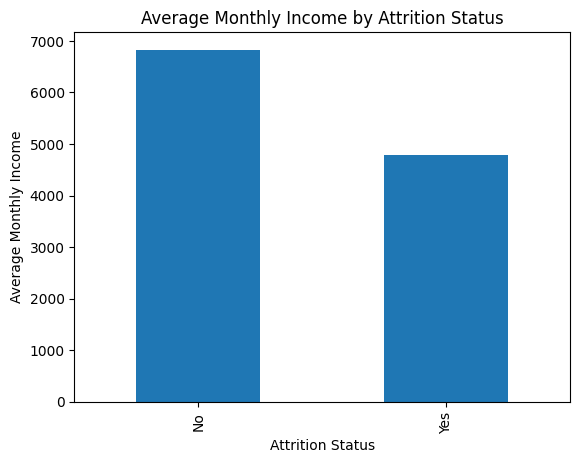

In [11]:
# Visualize average monthly income by attrition status
avg_salary.plot(kind='bar')
plt.title("Average Monthly Income by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Monthly Income")
plt.show()


## Insight:
There is a noticeable disparity in the average salary between employees who have experienced attrition and those who have not, indicating that compensation levels may be a contributing factor to employee turnover.


## Question 4:
Are younger employees more likely to leave the company?

In [ ]:
# Calculate average age by attrition status
avg_age = df.groupby('Attrition')['Age'].mean()
avg_age.round(2)

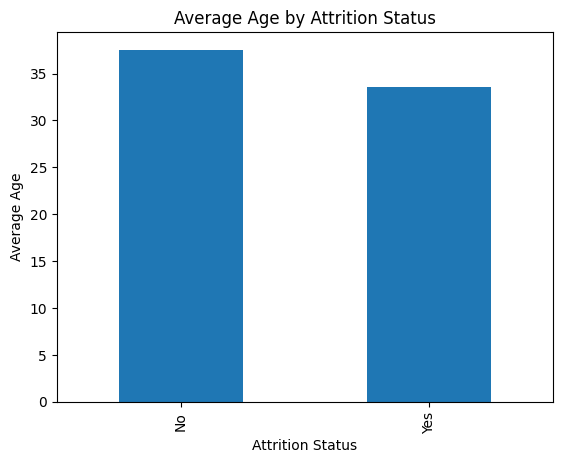

In [13]:
# Visualize average age by attrition status
avg_age.plot(kind='bar')
plt.title("Average Age by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Age")
plt.show()

## Insight:

The analysis shows that employees in the attrition group have a lower average age compared to those in the non-attrition group, suggesting that younger employees may be more likely to leave the organization.


## Question 5:
Do employees with fewer years at the company show higher attrition?


In [ ]:
# Calculate average tenure by attrition status
avg_tenure = df.groupby('Attrition')['YearsAtCompany'].mean()
print(avg_tenure.round(2))

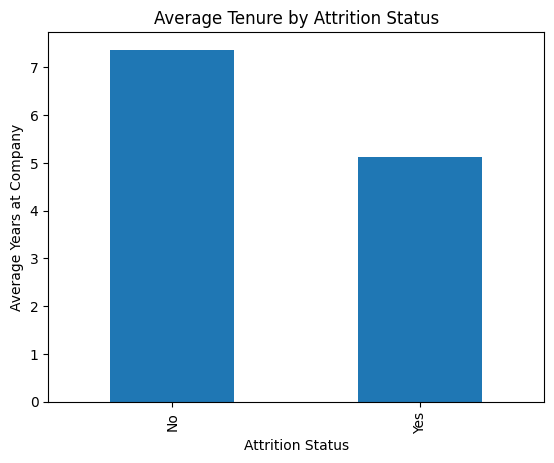

In [15]:
# Visualize average tenure by attrition status
avg_tenure.plot(kind='bar')
plt.title("Average Tenure by Attrition Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Years at Company")
plt.show()

## Insight:
There is a significant difference in tenure between the attrition and non-attrition groups, indicating that employee length of service may have a strong relationship with turnover trends.

## Question 6:
Is there a relationship between job level and employee retention?

In [ ]:
# Calculate attrition percentage by job level
job_level_attrition = pd.crosstab(df['JobLevel'], df['Attrition'], normalize='index') * 100
print(job_level_attrition.round(2))

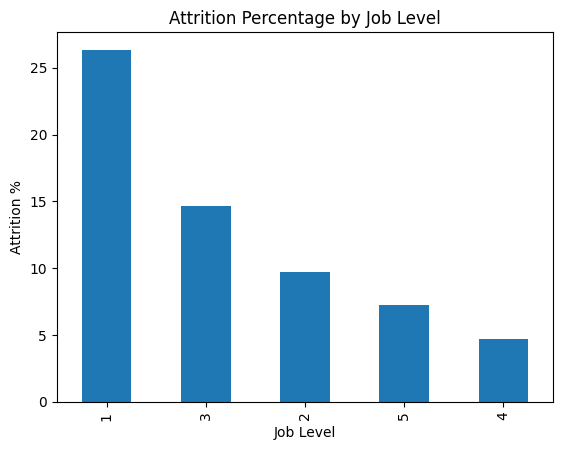

In [18]:
# Visualize attrition percentage by job level
job_level_attrition['Yes'].sort_values(ascending=False).plot(kind='bar')
plt.title("Attrition Percentage by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition %")
plt.show()

## Insight:

The attrition rate is highest among employees at Job Level 1 and gradually declines across higher job levels, suggesting that entry-level employees are more likely to leave the organization compared to those in senior positions.


## Question 7:
Which departments have the highest and lowest average salaries?

In [ ]:
# Calculate average monthly income by department
dept_avg_salary = df.groupby('Department')['MonthlyIncome'].mean()
print(dept_avg_salary.round(2))

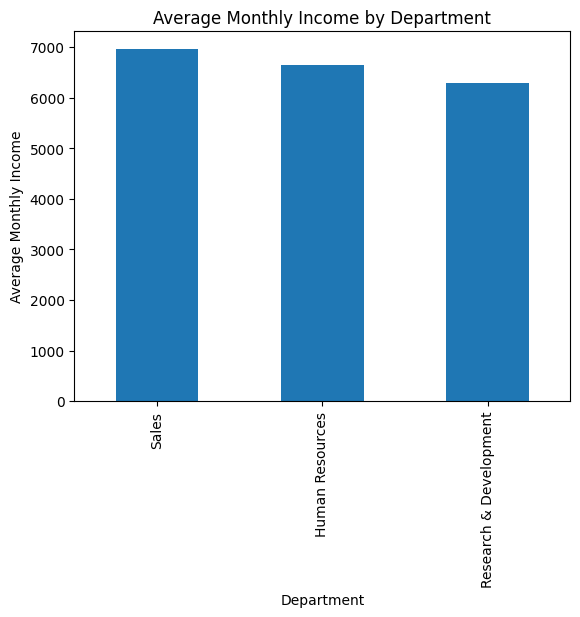

In [20]:
# Visualize average monthly income by department
dept_avg_salary.sort_values(ascending=False).plot(kind='bar')
plt.title("Average Monthly Income by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.show()

## Insight:
Sales department has the highest average monthly income, while Human Resources has the lowest average salary among all departments.

## Question 8:
How does employee age vary between employees who stay and those who leave?

In [ ]:
# Generate descriptive statistics for age by attrition status
df.groupby('Attrition')['Age'].describe()

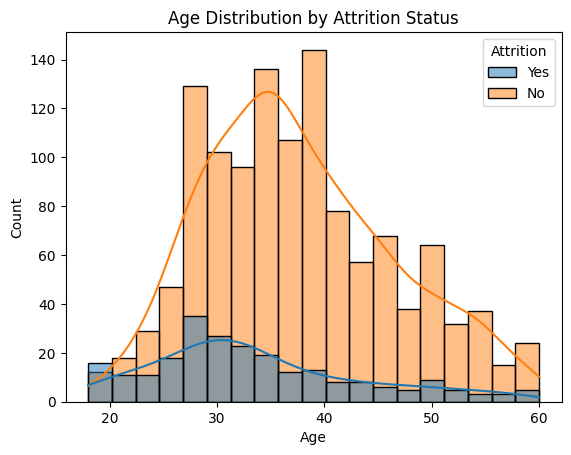

In [22]:
# Visualize age distribution by attrition status
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, multiple='layer')
plt.title("Age Distribution by Attrition Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Insight:

Attrition appears more common among younger employees, with a noticeable peak around the 27–28 age group. In contrast, older employees show relatively better retention, suggesting that early-career employees may be more prone to leaving the company.

## Question 9:
Does employee attrition vary by gender?



In [ ]:
# Calculate attrition percentage by gender
gender_attrition = pd.crosstab(df['Gender'], df['Attrition'], normalize='index') * 100
print(gender_attrition.round(2))

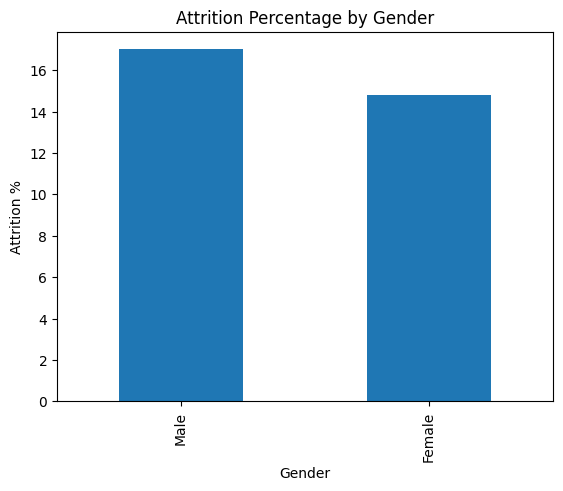

In [25]:
# Visualize attrition percentage by gender
gender_attrition['Yes'].sort_values(ascending=False).plot(kind='bar')
plt.title("Attrition Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Attrition %")
plt.show()

## Insight:
Attrition rates appear to vary slightly across gender groups. However, the difference is not extreme, suggesting that gender alone may not be a strong predictor of employee attrition in this dataset.

## Question 10:
Are there salary differences across genders?


In [ ]:
# Calculate average monthly income by gender
gender_salary = df.groupby('Gender')['MonthlyIncome'].mean()
print(gender_salary.round(2))

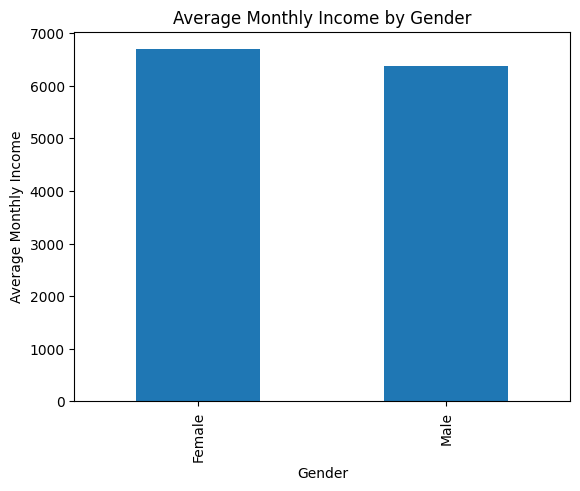

In [27]:
# Visualize average monthly income by gender
gender_salary.plot(kind='bar')
plt.title("Average Monthly Income by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Monthly Income")
plt.show()

## Insight:

There is no significant difference in average salary across gender groups, suggesting that compensation is relatively consistent and does not vary meaningfully by gender in this dataset.

## Question 11:
What key factors are most strongly associated with employee attrition?

## Insight:

The key factors associated with employee attrition in this analysis are monthly income, age, and years at the company. Employees who left the organization generally had lower salaries, were younger, and had shorter tenure compared to those who stayed.

This suggests that early-career employees in lower salary brackets are more likely to leave, indicating potential gaps in onboarding, career development opportunities, and compensation progression.

## Question 12:
 What are the potential risks if current attrition trends continue?

## Insight:

If the current attrition trends continue, the company may face several significant risks. High turnover among younger employees and those with lower tenure can lead to increased recruitment and training costs, loss of organizational knowledge, and reduced productivity.

Departments with higher attrition rates may experience instability, impacting team performance and workload distribution. Over time, this could also affect employee morale, as remaining employees may experience increased pressure and burnout.

Additionally, continuous loss of early-career employees may indicate challenges in onboarding, career development, or engagement strategies, which could harm long-term workforce sustainability.

## Question 13:
What recommendations can be made to reduce employee turnover in the future?


## Recommendations:

1. Improve Early-Career Retention:
Since attrition is higher among younger and low-tenure employees, the company should strengthen onboarding programs, mentorship opportunities, and early career support to help new employees integrate and grow.

2. Review Compensation Strategy:
Employees with lower monthly income show higher attrition. The company should ensure competitive and fair salary structures, especially for entry-level and high-pressure roles.

3. Career Growth Opportunities:
Introduce clear career progression paths, internal promotions, and skill development programs to reduce employee exit due to lack of growth.

4. Department-Specific Interventions:
Departments with higher attrition rates should be analyzed individually to identify issues such as workload, management style, or team structure, and targeted improvements should be implemented.

5. Employee Engagement & Work Environment:
Improve job satisfaction through better manager-employee communication, recognition programs, and workload balance initiatives to reduce burnout and dissatisfaction.

6. Retention Monitoring System:
Implement a dashboard to continuously monitor attrition trends across departments, job roles, and employee groups to take proactive action rather than reactive decisions.

## Final Conclusion:
The analysis identified salary, age, tenure, and department-level differences as major contributors to employee attrition. Younger and lower-tenure employees were more likely to leave the company. Strategic improvements in onboarding, compensation, and career growth can help improve retention.